## Top 10 movies by average ratings

In [1]:
import pandas as pd

In [2]:
import pyodbc

for driver in pyodbc.drivers():
    print(driver)   #checking what all drivers installed in this machine

SQL Server
Microsoft Access Driver (*.mdb, *.accdb)
Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)
Microsoft Access Text Driver (*.txt, *.csv)
Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)
SQL Server Native Client RDA 11.0
ODBC Driver 17 for SQL Server
ODBC Driver 18 for SQL Server


In [3]:
import pyodbc
con = pyodbc.connect(DRIVER = '{ODBC Driver 17 for SQL Server}', SERVER = '.', DATABASE = 'DA07_movieDB', Trusted_Connection = 'Yes', autocommit = 'True')
print('DB Connected successfully')

DB Connected successfully


In [8]:
# 2. Paste your exact working SQL query here


query = """SELECT TOP 10 m.movie_id,m.name, AVG(r.rating) AS average_rating FROM movies m
INNER JOIN ratings r 
    ON m.movie_id = r.movie_id
GROUP BY 
    m.movie_id, 
    m.name
ORDER BY 
    average_rating DESC;"""

try:
    df_top_movies_by_rating = pd.read_sql(query, con)
    
    # 4. Display the data table
    print("--- Top 10 Movies Data Set ---")
    print(df_top_movies_by_rating)

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # 5. Always close the connection when done
    con.close()

--- Top 10 Movies Data Set ---
   movie_id                                             name  average_rating
0       524                                             Rudy             5.0
1      1166                                   Farmer & Chase             5.0
2      2766                 The Adventures Of Sebastian Cole             5.0
3      1152                               He Walked By Night             5.0
4       986                                    Fly Away Home             5.0
5      3683                                     Blood Simple             5.0
6       692                                             Solo             5.0
7       807  Rendezvous In Paris (Rendez-Vous De Paris, Les)             5.0
8      2954                                     Penitentiary             5.0
9       790                          An Unforgettable Summer             4.9


C:\Users\SajayN\AppData\Local\Temp\ipykernel_45988\3679207992.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_movies_by_rating = pd.read_sql(query, con)


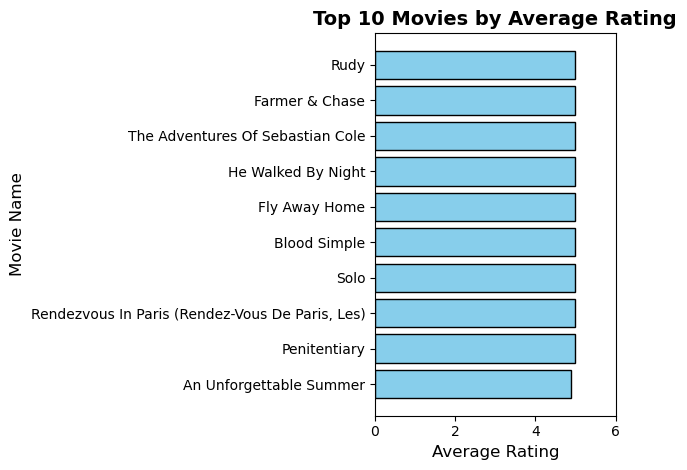

In [24]:
import matplotlib.pyplot as plt
try:
    # 4. Create the horizontal bar chart
    # 'barh' creates horizontal bars: y-axis = movie name, x-axis = rating
    plt.barh(df_top_movies_by_rating['name'], df_top_movies_by_rating['average_rating'], color='skyblue', edgecolor='black')
    
    # 5. Customize the graph appearance
    plt.gca().invert_yaxis()  # Puts the #1 highest-rated movie at the top
    plt.xlabel('Average Rating', fontsize=12)
    plt.ylabel('Movie Name', fontsize=12)
    plt.title('Top 10 Movies by Average Rating', fontsize=14, fontweight='bold')
    
   # Give the x-axis a tiny bit of extra room for labels
    plt.xlim(0, max(df_top_movies_by_rating['average_rating']) + 1)
    
    # Automatically adjusts spacing so long full names are fully visible
    plt.tight_layout()
    
    # 6. Display the graph window
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [13]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


C:\Users\SajayN\AppData\Local\Temp\ipykernel_47952\438664991.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


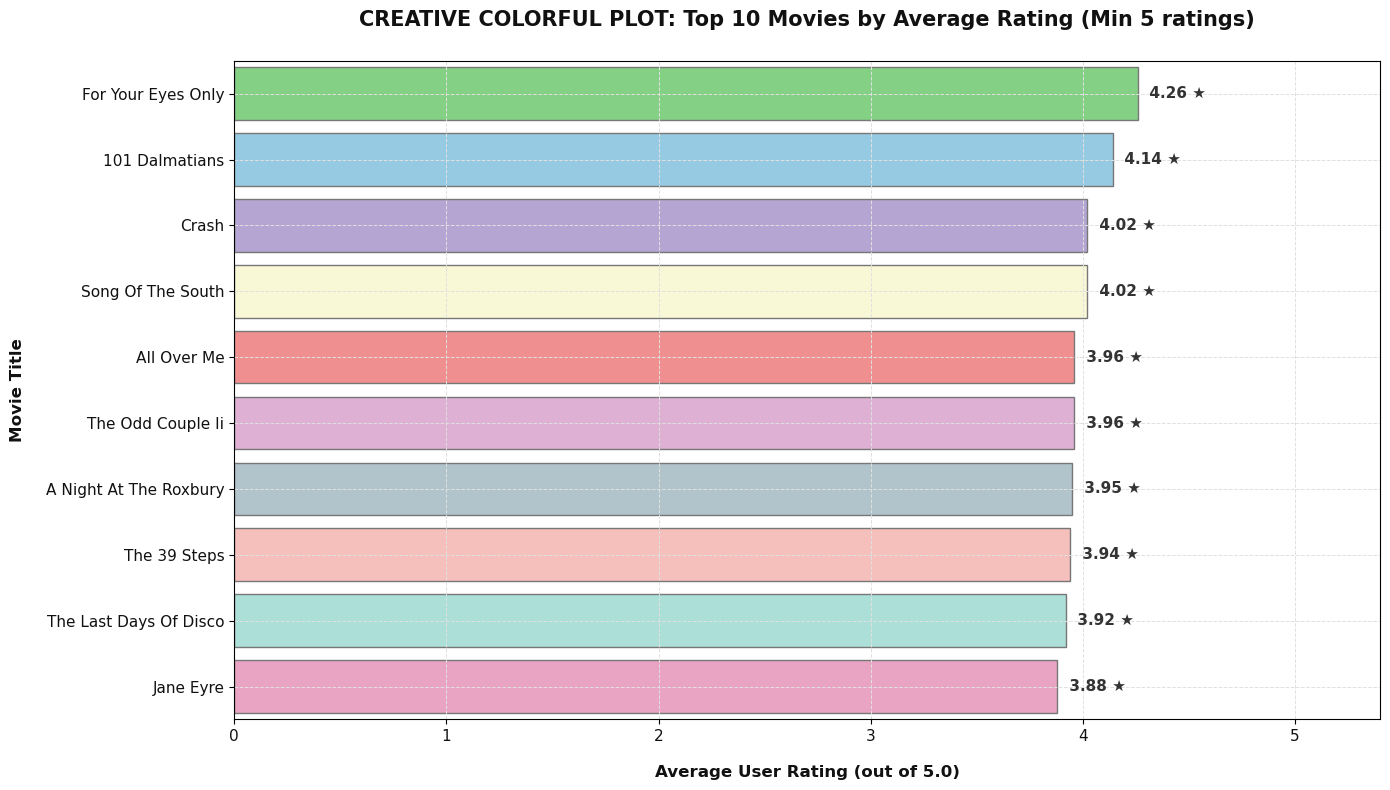

In [5]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Fetching top 10 movies with minimum 5 ratings requirement
query = """
SELECT TOP 10
    m.name AS movie_name,
    ROUND(AVG(CAST(r.rating AS FLOAT)), 2) AS average_rating,
    COUNT(r.rating) AS total_ratings_count
FROM [dbo].[Movies] m
INNER JOIN [dbo].[ratings] r 
    ON m.movie_id = r.movie_id
GROUP BY 
    m.movie_id, 
    m.name
HAVING 
    COUNT(r.rating) >= 5
ORDER BY 
    average_rating DESC, 
    total_ratings_count DESC;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Define the lighter, pastel multi-color list for the 10 bars
lighter_creative_colors = [
    '#77DD77',  # 1. Pastel Green
    '#89CFF0',  # 2. Baby Blue
    '#B39DDB',  # 3. Light Purple / Lavender
    '#FFFDD0',  # 4. Cream / Soft Yellow
    '#FF7F7F',  # 5. Light Red / Pastel Coral
    '#E6A8D7',  # 6. Orchid / Soft Violet
    '#AEC6CF',  # 7. Pastel Indigo / Slate Blue
    '#FFB7B2',  # 8. Pastel Pink / Melon
    '#A2E8DD',  # 9. Pale Teal / Mint
    '#F498C2'   # 10. Pastel Magenta
]

bar_colors = lighter_creative_colors[:len(df)]

# 4. Setup the Interface Canvas with a White Background
plt.figure(figsize=(14, 8), facecolor='#FFFFFF') 
ax = plt.gca()
ax.set_facecolor('#FFFFFF')

# Create the horizontal bar plot using our lighter color list
sns.barplot(
    x='average_rating', 
    y='movie_name', 
    data=df, 
    palette=bar_colors,
    hue='movie_name',
    legend=False,
    edgecolor='#777777',  # Soft gray border around bars
    linewidth=1
)

# 5. Cleaned Styling: Special character removed, title ends with (Min 5 ratings)
plt.title('CREATIVE COLORFUL PLOT: Top 10 Movies by Average Rating (Min 5 ratings)', 
          fontsize=15, fontweight='bold', color='#111111', pad=25)

plt.xlabel('Average User Rating (out of 5.0)', fontsize=12, fontweight='bold', color='#111111', labelpad=15)
plt.ylabel('Movie Title', fontsize=12, fontweight='bold', color='#111111', labelpad=15)

# Style tick marks
plt.xticks(color='#111111', fontsize=11)
plt.yticks(color='#111111', fontsize=11)
plt.grid(color='#E0E0E0', linestyle='--', linewidth=0.7) 

# Adjust X-axis ceiling limits for clean text tracking space
plt.xlim(0, 5.4) 

# 6. Clean Bar Data Labels
for i, p in enumerate(ax.patches):
    width = p.get_width()
    rating = df.iloc[i]['average_rating']
    
    label_text = f" {rating:.2f} ★"
    
    ax.text(
        width + 0.03, 
        p.get_y() + p.get_height() / 2, 
        label_text, 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='#333333'
    )

# Optimize layout constraints
plt.tight_layout()
plt.show()